# Check energy landscape as function of $\alpha$ : 4 x 4 

In [1]:
import tqdm as tqdm
import netket as nk
import jax
import jax.numpy as jnp
import sys
import os

/Users/user/Desktop/EPFL/MA2/TPIV/project-tp/.env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

In [2]:
verbose = True

In [3]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.lancoz_alpha_opt import lanczos_ansatz, _logpsi_lanczos
from src.plot_VMC import *
from src.utils import *
from src.plot.plot_graph import *
from src.plot.plot_alpha import *
from src.ener_landscape import *

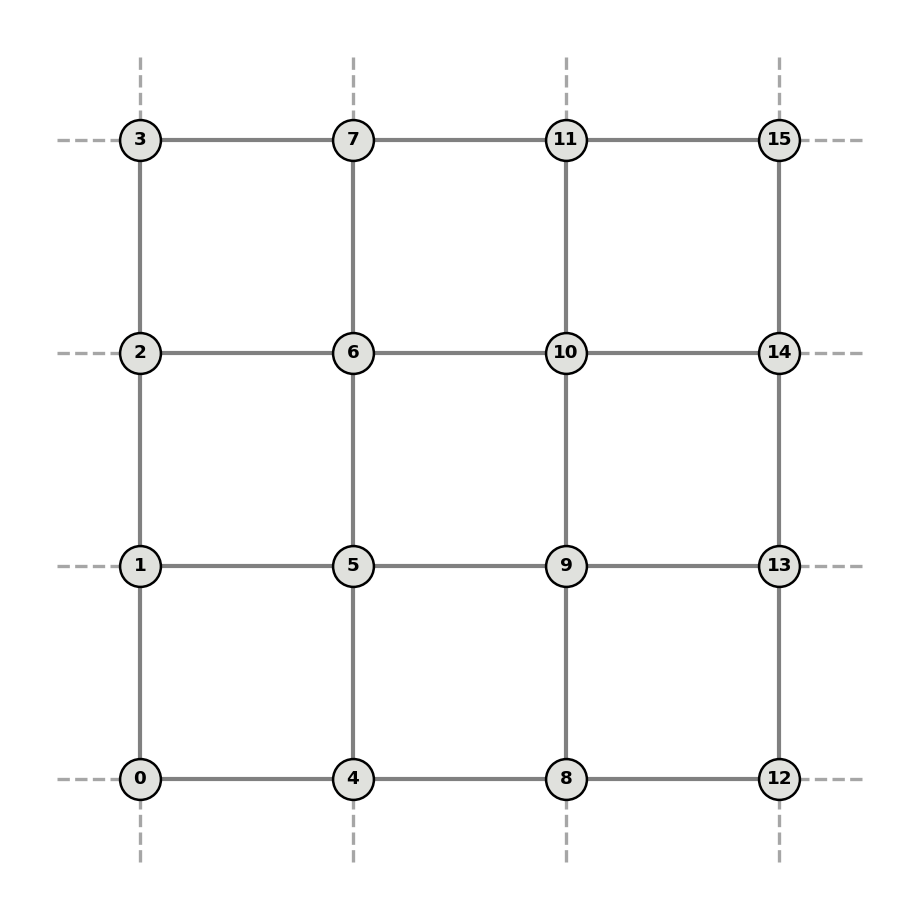

In [4]:
# Defining the Hamiltonian
L = 4
graph = nk.graph.Hypercube(length=L, n_dim=2, pbc=True) # correspond a J2 = 0
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=graph.n_nodes)
ha = 0.25 * nk.operator.Heisenberg(hilbert=hi, graph=graph, sign_rule=True) 
plot_netket_graph(graph, layout='square_pbc')

The exact ground-state energy is E0 = -11.228483208428854


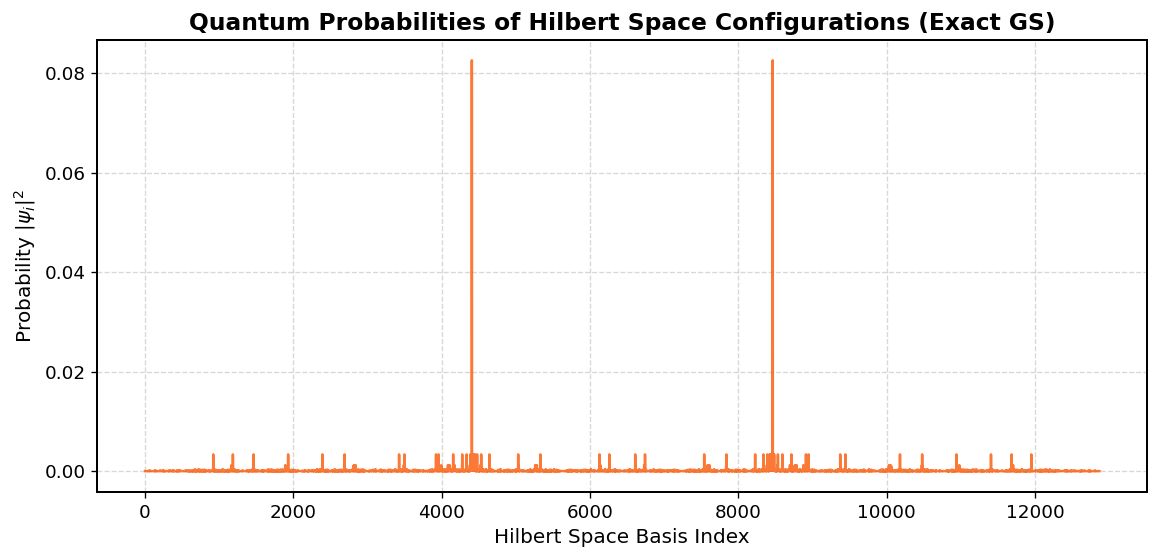

In [5]:
# Exact Diagonalization
evals, eigs = nk.exact.lanczos_ed(ha, compute_eigenvectors=True)
exact_gs_energy = evals[0]
if verbose:
    print("The exact ground-state energy is E0 =", exact_gs_energy)

psi_0 = eigs[:, 0] if eigs.ndim > 1 else eigs
probabilites = np.abs(psi_0)**2


plt.figure(figsize=(10, 5), dpi=120)

plt.plot(probabilites, color='#fa5703', alpha=0.8, linewidth=1.5)

plt.title("Quantum Probabilities of Hilbert Space Configurations (Exact GS)", fontsize=14, fontweight='bold')
plt.xlabel("Hilbert Space Basis Index", fontsize=12)
plt.ylabel(r"Probability $|\psi_i|^2$", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
# hyperparameters for the VMC optimization
diag_shift = 1e-4                       # The diagonal regularization parameter
learning_rate = 1e-2                  # learning rate
n_samples = 4096                        # number of samples
n_iter = 50                             # number of iterations (reduce # of ti to see impvoement of lancoz)
alpha = 1                               # feature density. Number of features equal to alpha * input.shape[-1]

# data directory
data_file = f"../../datas/datas_alpha_iter_hypercube_{n_iter}"
dir_init = data_file + "/RBM_VMC"

# hyperparameters for the alpha optimization
lr_alpha = 1e-2                         # learning rate for the alpha optimization
n_iter_alpha = 100                      # number of iterations for the alpha optimization
dir_alpha = data_file + "/RBM_alpha"    # directory to save the results of the alpha optimization
alpha_init = 0.5                        # initial value of alpha for the alpha optimization
num_it = 1000                           # number of iterations for the lanczos ansatz

if not os.path.exists(data_file):
    os.makedirs(data_file)
    print(f"The file {data_file}' has just been created.")
else:
    print(f"The file {data_file} already exists.")

hyperparameters = {
    "data_file": data_file,
    "dir_init": dir_init,
    "dir_alpha": dir_alpha,
    "diag_shift": diag_shift,
    "learning_rate": learning_rate,
    "n_samples": n_samples,
    "n_iter": n_iter,
    "feature_density_alpha": alpha,
    "lr_alpha": lr_alpha,
    "n_iter_alpha": n_iter_alpha,
    "alpha_init": alpha_init,
    "num_it": num_it
}
json_path = os.path.join(data_file, "hyperparameters.json")

with open(json_path, 'w') as f:
    json.dump(hyperparameters, f, indent=4) 

print(f"Paramètres sauvegardés avec succès dans {json_path}")

if verbose :
    print(f" -> diag_shift : {diag_shift}")
    print(f" -> learning rate : {learning_rate}")
    print(f" -> # samples : {n_samples}")
    print(f" -> # iterations : {n_iter}")
    print(f" -> feature density : {alpha}")

The file ../../datas/datas_alpha_iter_hypercube_50' has just been created.
Paramètres sauvegardés avec succès dans ../../datas/datas_alpha_iter_hypercube_50/hyperparameters.json
 -> diag_shift : 0.0001
 -> learning rate : 0.01
 -> # samples : 4096
 -> # iterations : 50
 -> feature density : 1


In [7]:
# Learning with a Restricted Boltzmann Machine (RBM)
model = nk.models.RBM(alpha=alpha)
sampler = nk.sampler.MetropolisExchange(hilbert=hi, graph=graph)
optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
vs_init = nk.vqs.MCState(sampler, model, n_samples=n_samples)
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=diag_shift, 
    variational_state=vs_init
)
gs.run(out= dir_init, n_iter=n_iter)

Automatic SR implementation choice:  QGT


100%|██████████| 50/50 [00:06<00:00,  7.70it/s, Energy=-11.1305 ± 0.0098 [σ²=2.9e-01, R̂=1.004]]


(JsonLog('../../datas/datas_alpha_iter_hypercube_50/RBM_VMC', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.02335500717163086
   	Params: 0.022445201873779297,)

✅ Figure saved as ../../datas/datas_alpha_iter_hypercube_50/VMC_init_metrics.png


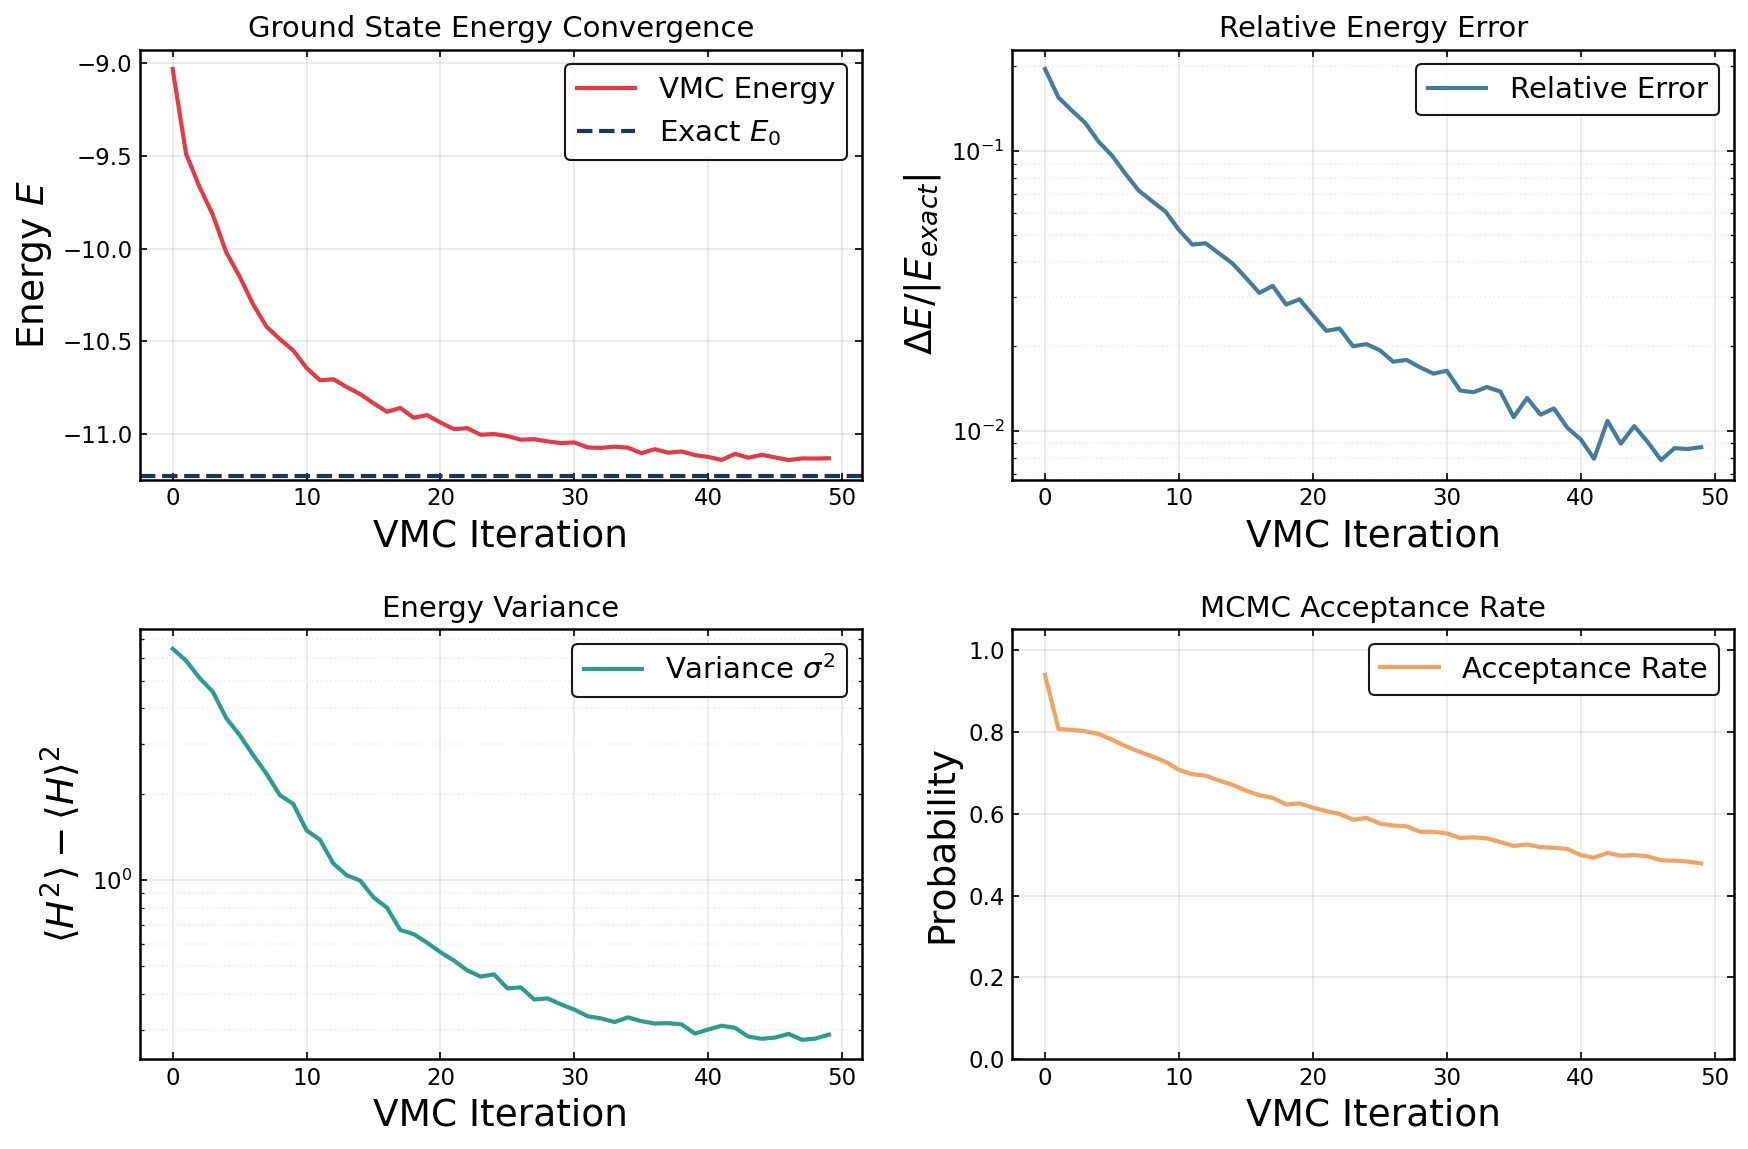

In [8]:
with open(data_file + "/RBM_VMC.log") as f:
    data = json.load(f)
    
iters_RBM = np.array(data["Energy"]["iters"])
energy_RBM = np.array(data["Energy"]["Mean"])
variance_RBM = np.array(data["Energy"]["Variance"])
acceptance_RBM = np.array(data["acceptance"]["value"])

relative_error = np.abs(energy_RBM - exact_gs_energy) / np.abs(exact_gs_energy)

if verbose:
    plot_VMC(f"{data_file}/RBM_VMC.log", exact_gs_energy, save_fig=True, fig_name=f"{data_file}/VMC_init_metrics.png")

MCMC Sampling & Reweighting: 100%|██████████| 2000/2000 [1:07:15<00:00,  2.02s/it]



Running Robust Moving-Average Bootstrap for Error Estimation...


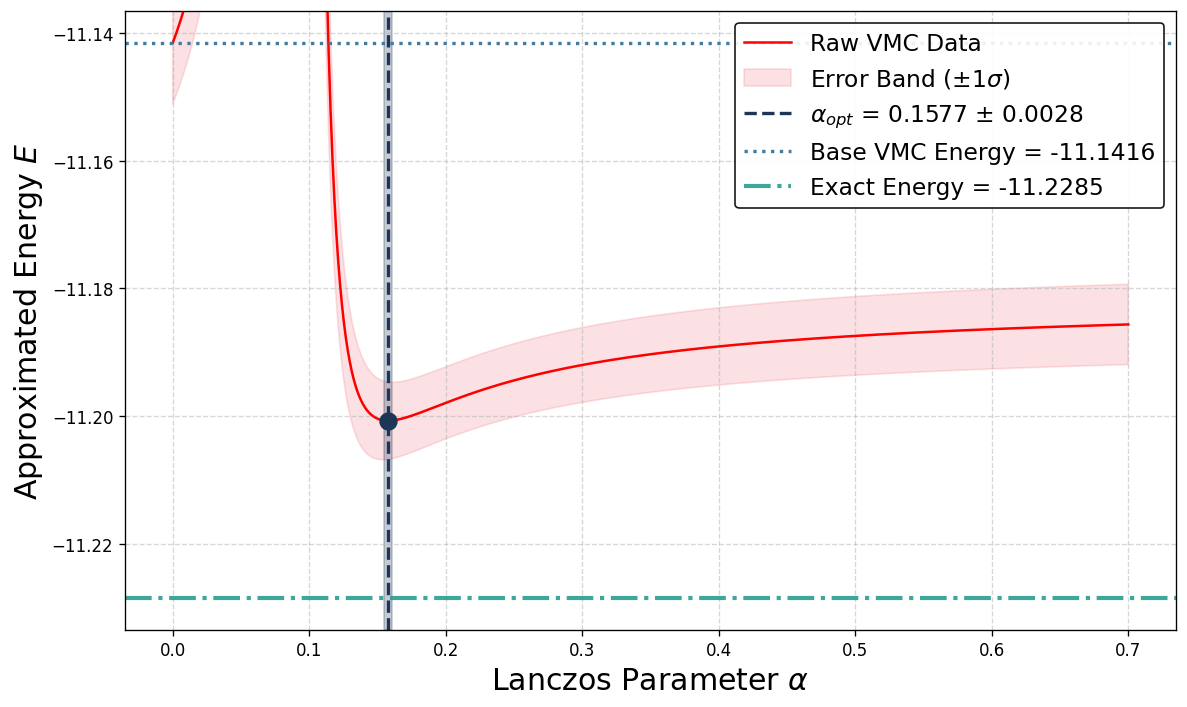

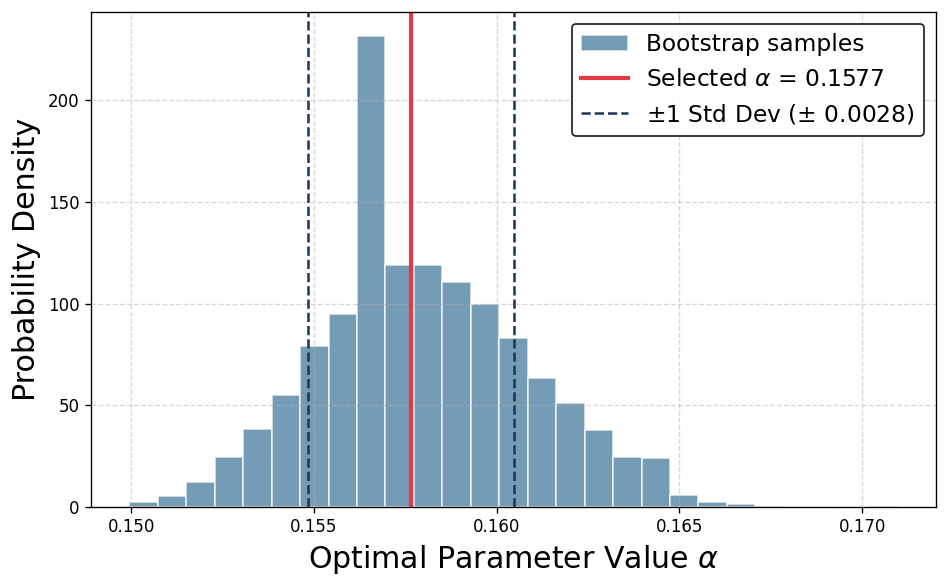

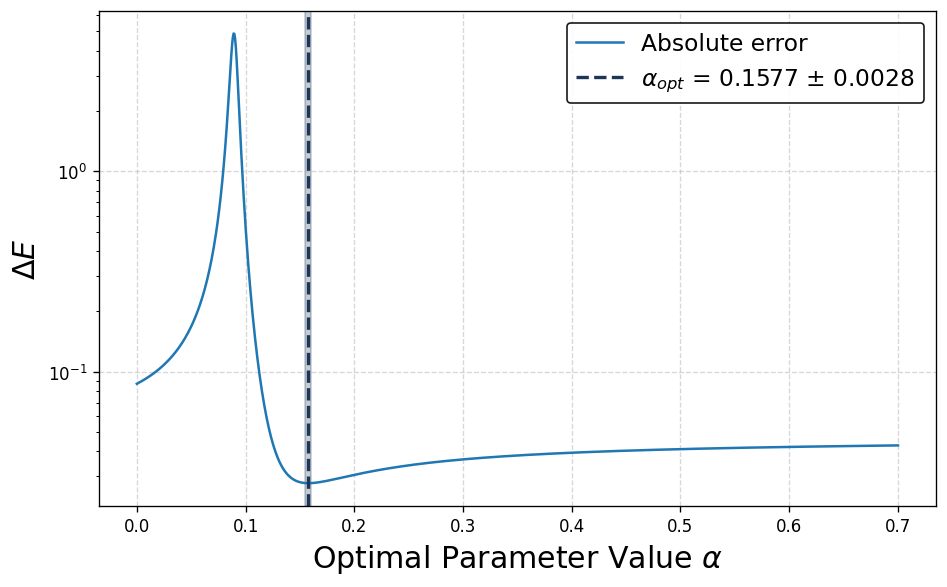


➔ EXACT MA ALPHA  : 0.15766 ± 0.00282
➔ ENERGY GAIN     : 0.05918 (VMC: -11.1416 ➔ Lanczos: -11.2007)


In [9]:
# --- Hyperparamètres ---
h2 = ha @ ha
alphas_to_test = np.linspace(0.0, 0.7, 1000)
N_MCMC_STEPS = 2000
N_BOOTSTRAP = 10000
SAVE_DIRECTORY = "../../assets"

energies_mean, energies_std, e_vmc = compute_lanczos_landscape(
    vs_init=vs_init, 
    ha=ha, 
    h2=h2, 
    alphas_to_test=alphas_to_test, 
    n_mcmc_steps=N_MCMC_STEPS
)

bootstrap_results = extract_optimal_alpha_bootstrap(
    alphas_to_test=alphas_to_test, 
    energies_mean=energies_mean, 
    energies_std=energies_std, 
    n_mcmc_steps=N_MCMC_STEPS,
    n_bootstrap=N_BOOTSTRAP
)

plot_lanczos_results(
    alphas_to_test=alphas_to_test, 
    energies_mean=energies_mean, 
    energies_std=energies_std, 
    e_vmc=e_vmc, 
    exact_gs_energy=exact_gs_energy, 
    bootstrap_results=bootstrap_results, 
    save_dir=SAVE_DIRECTORY
)

In [10]:
afun_original = lambda x: vs_init._apply_fun(vs_init.variables, x) # Figer l'ancienne RBM (Le monde statique)

lanczos_model = lanczos_ansatz(alpha_init=alpha_init, dtype=jnp.complex128)

dummy_logpsi = jnp.zeros((1,), dtype=jnp.complex128)
dummy_eloc = jnp.zeros((1,), dtype=jnp.complex128) # donnee manequin pour init eloc (jutse donner la taille)

key = jax.random.PRNGKey(0)
lanczos_variables = lanczos_model.init(key, dummy_logpsi, dummy_eloc) # lanczos_variables contient UNIQUEMENT {'params': {'alpha': 0.01}}

apply_lanczos = nk.jax.HashablePartial(
    _logpsi_lanczos, afun_original, ha
)

vstate_lanczos = nk.vqs.MCState(
    sampler=vs_init.sampler,
    apply_fun=apply_lanczos,
    n_samples=vs_init.n_samples,
    variables=lanczos_variables, 
    n_discard_per_chain=vs_init.n_discard_per_chain, # Nombre d'échantillons à jeter par chaîne (thermalisation)
)

print("Variables de l'état :", vstate_lanczos.variables)

/Users/user/Desktop/EPFL/MA2/TPIV/project-tp/.env/lib/python3.11/site-packages/jax/_src/lax/lax.py:3385: ComplexWarning: Casting complex values to real discards the imaginary part
  fill_value = _convert_element_type(fill_value, fill_dtype, weak_type)


Variables de l'état : {'params': {'alpha': Array([0.5+0.j], dtype=complex128)}}


In [11]:
def track_alpha(step, log_data, driver):
    """
    Cette fonction est appelée par NetKet à CHAQUE itération.
    - step : le numéro de l'itération
    - driver : l'objet VMC qui contient tout notre état
    """
    valeur_alpha = driver.state.variables['params']['alpha']
    alpha_reel = valeur_alpha.real.item()
    historique_alpha.append(alpha_reel)
    
    return True

optimizer = nk.optimizer.Sgd(learning_rate=lr_alpha)
historique_alpha = []
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=False, 
    variational_state=vstate_lanczos
)
gs.run(n_iter=n_iter_alpha, out= dir_alpha, callback=track_alpha)

Automatic SR implementation choice:  QGT


100%|██████████| 100/100 [03:06<00:00,  1.87s/it, Energy=-11.2083+0.0000j ± 0.0055 [σ²=7.5e-02, R̂=1.006]]


(JsonLog('../../datas/datas_alpha_iter_hypercube_50/RBM_alpha', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.33984923362731934
   	Params: 0.28149914741516113,)

✅ Figure saved as ../../datas/datas_alpha_iter_hypercube_50/VMC_alpha_metrics.png


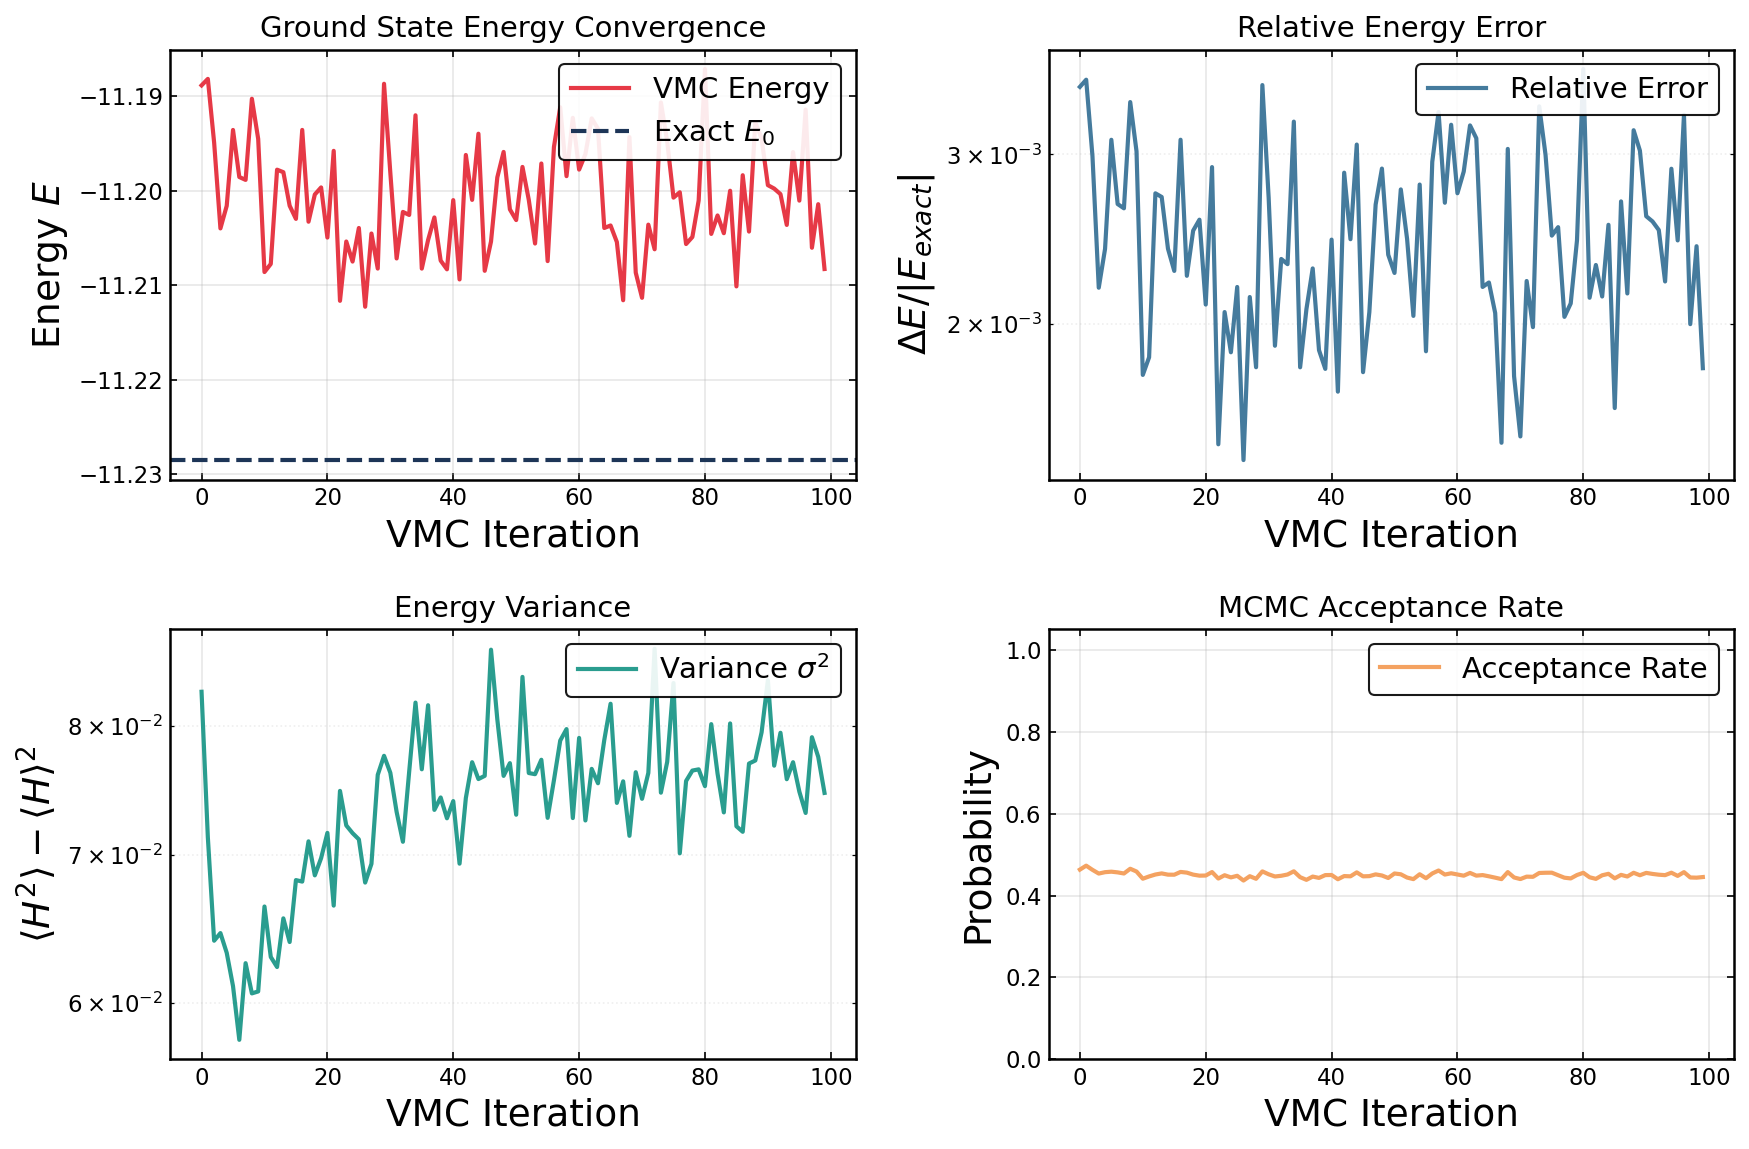

In [12]:
with open(data_file + "/RBM_alpha.log") as f:
    data = json.load(f)

if verbose:
    plot_VMC(f"{data_file}/RBM_alpha.log", exact_gs_energy, save_fig=True, fig_name=f"{data_file}/VMC_alpha_metrics.png")

✅ Figure saved as ../../datas/datas_alpha_iter_hypercube_50/VMC_Sequential_metrics.png


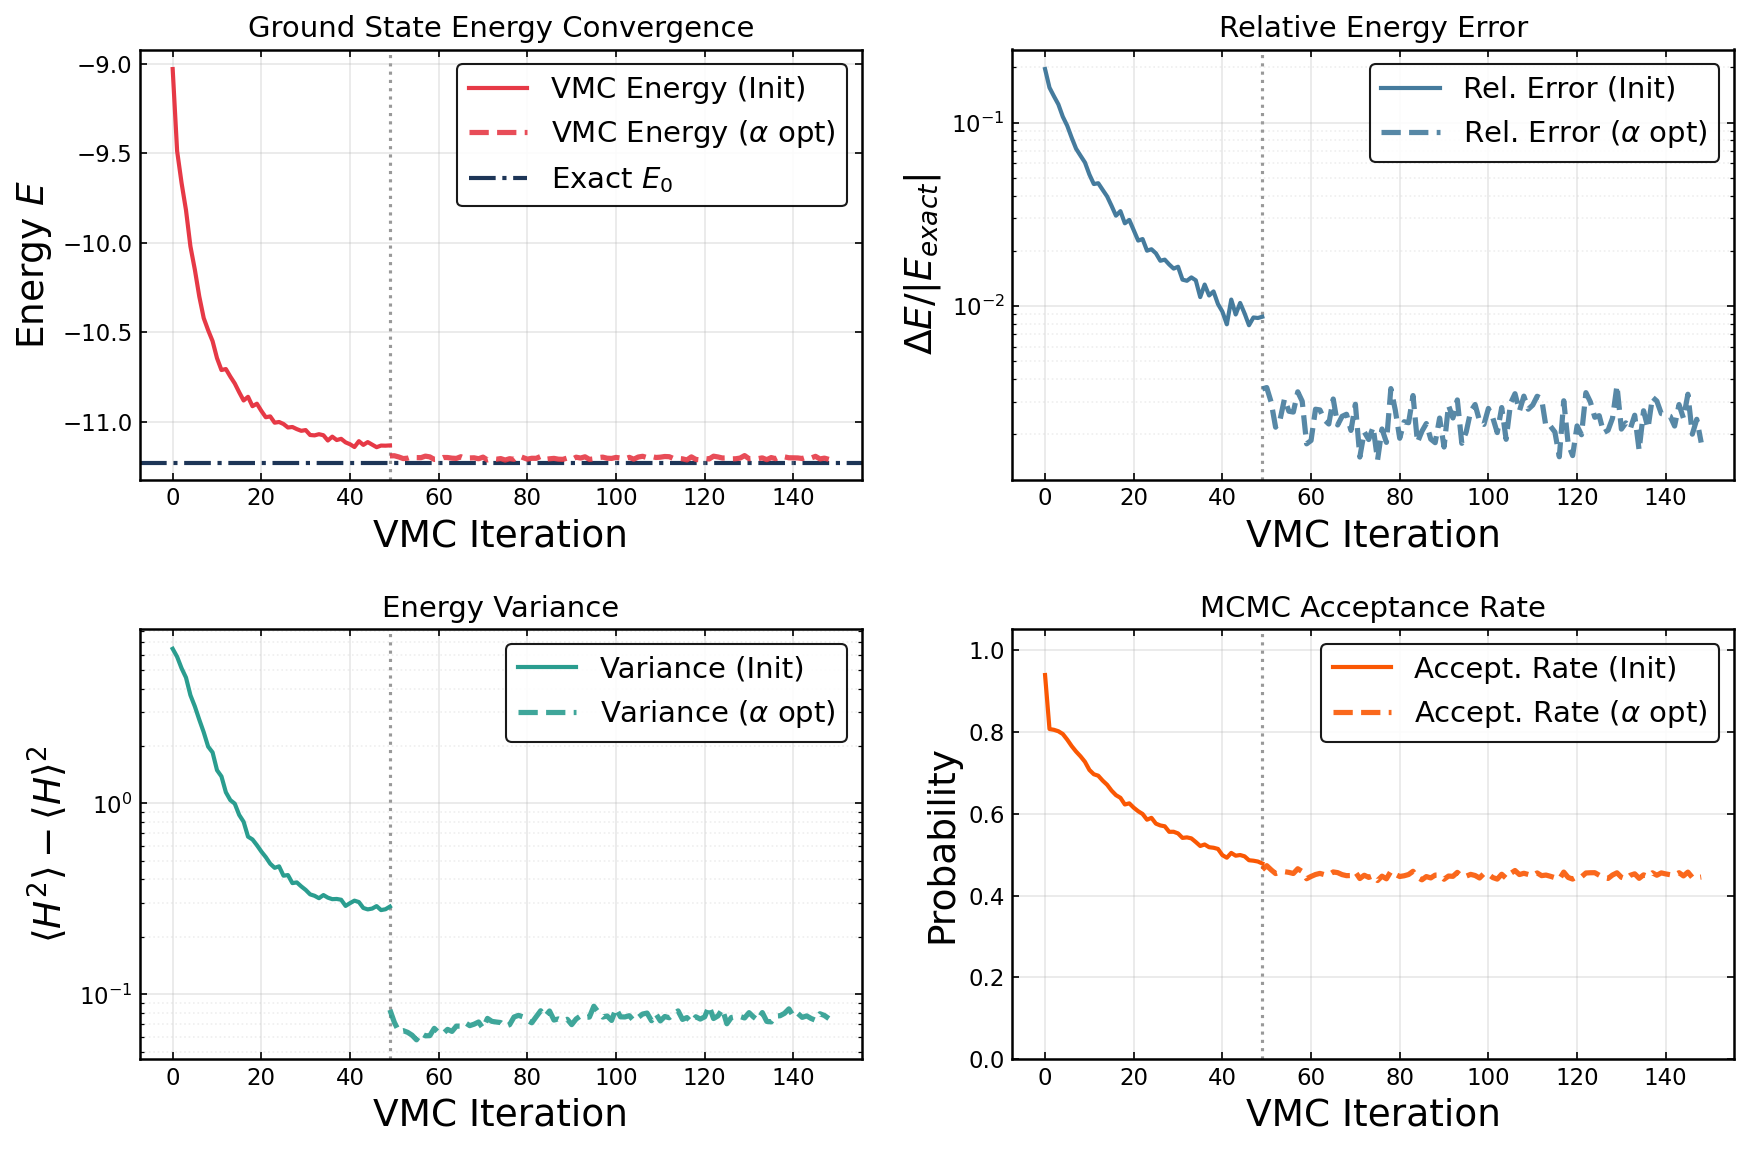

In [13]:
if verbose:
    file_init = f"{data_file}/RBM_VMC.log"
    file_alpha = f"{data_file}/RBM_alpha.log"
    
    plot_VMC_sequential(
        data_file_init=file_init,
        data_file_alpha=file_alpha,
        exact_gs_energy=exact_gs_energy,
        save_fig=True,
        fig_name=f"{data_file}/VMC_Sequential_metrics.png"
    )

 -> Target Bootstrap Alpha : 0.157658 ± 0.002819
 -> Optimized VMC Alpha    : 0.168786 ± 0.039556 (last 100 iters)


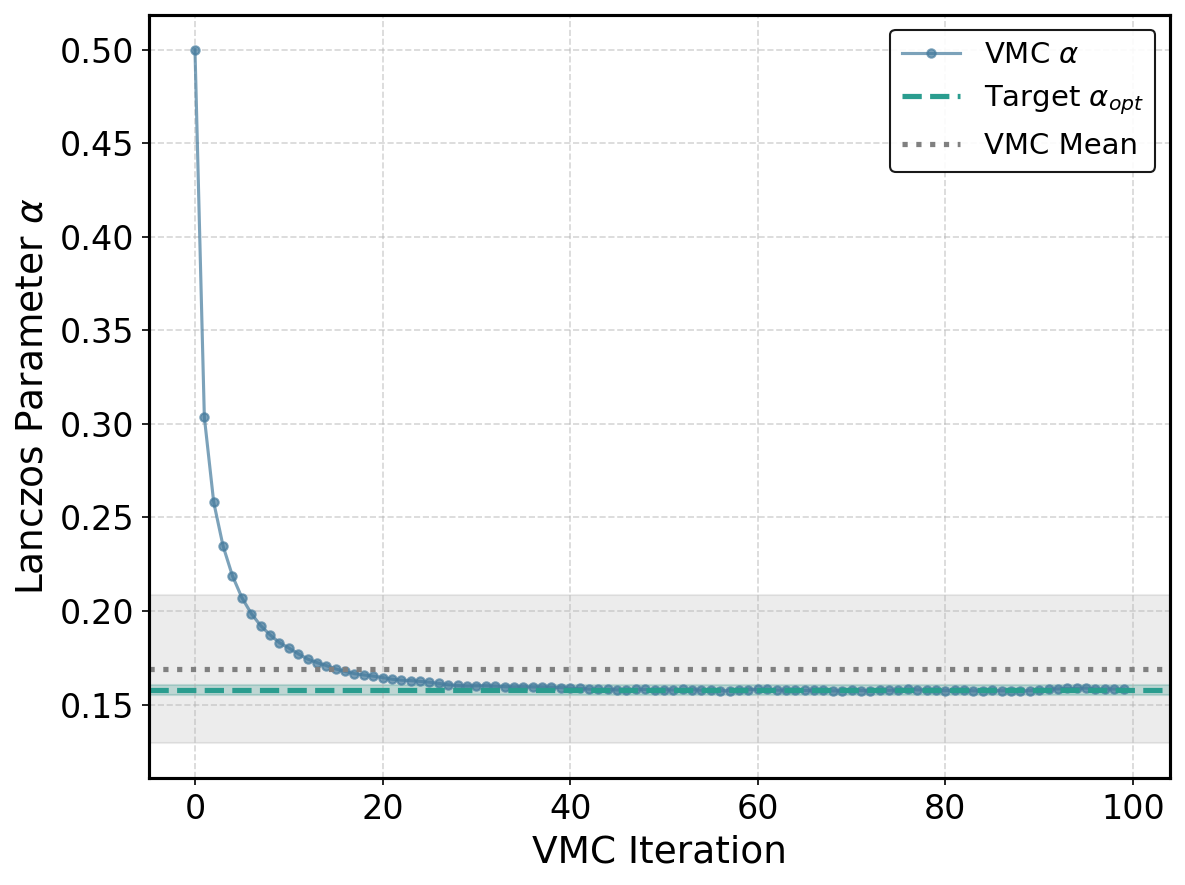

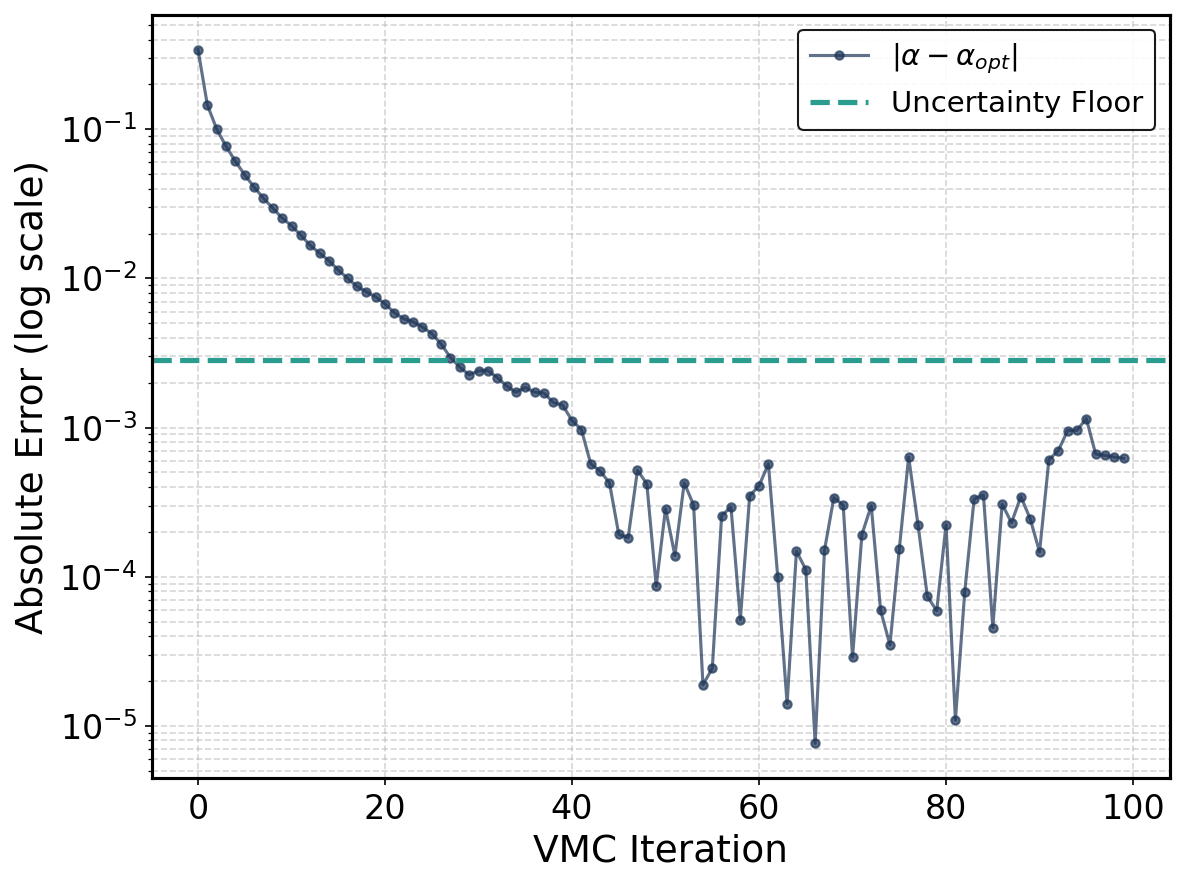

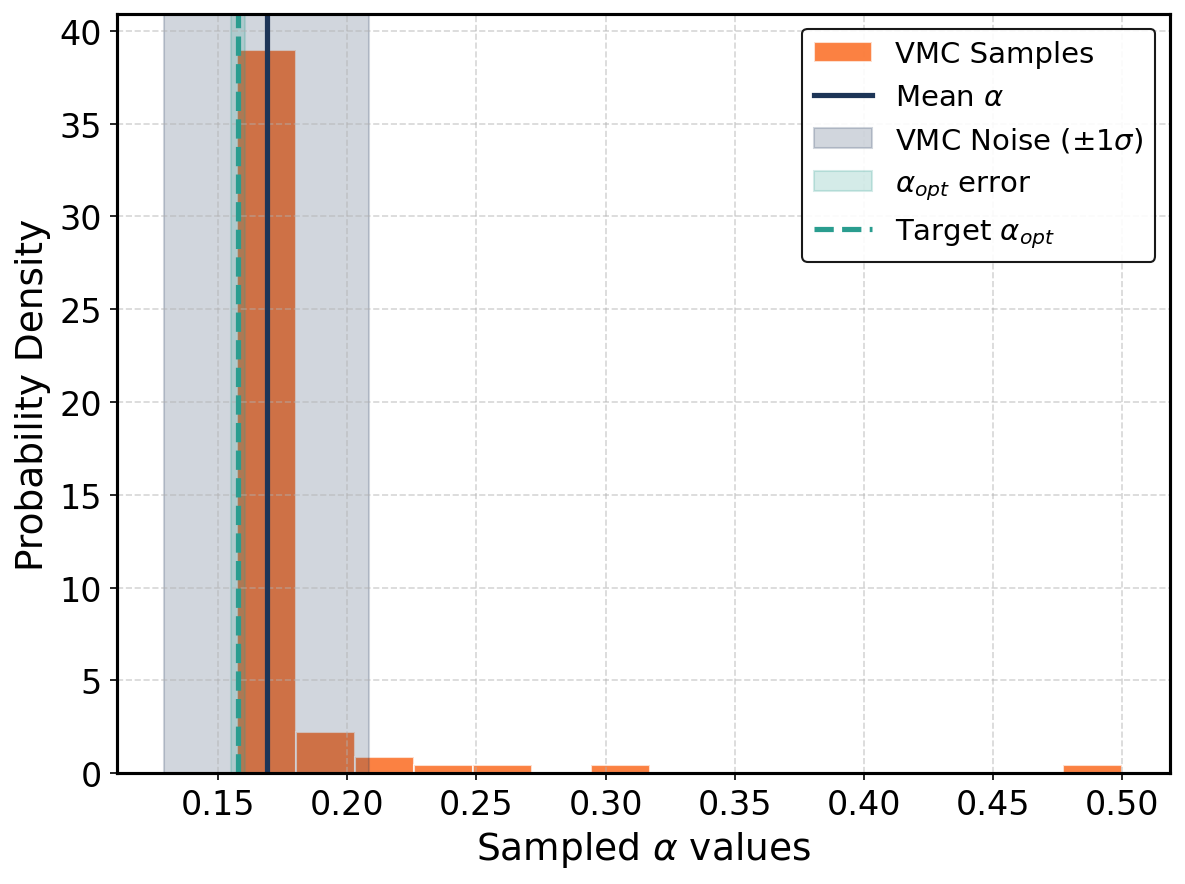

(np.float64(0.16878606751331193), np.float64(0.03955626572613614))

In [14]:
plot_alpha_convergence(
    historique_alpha, 
    alpha_min=bootstrap_results["alpha_opt_final"], 
    alpha_err=bootstrap_results["alpha_opt_err"]
)